In [3]:
# =========================================================
# XGBoost GPU - Group by student_id + VAL early stopping
# =========================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")

# Nếu bạn muốn tái lập kết quả ổn định hơn
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# XGBoost
from xgboost import XGBRegressor


In [4]:
# === 1) Load data ===
DATA_CANDIDATES = [
    "clean_student_data_v2.csv",
]

DATA_PATH = next((p for p in DATA_CANDIDATES if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Không tìm thấy clean_student_data_v2.csv. "
        "Hãy đặt file cùng thư mục notebook hoặc sửa DATA_CANDIDATES."
    )

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df.shape}")

# === 2) Target & drop columns (giữ đúng logic session 2) ===
TARGET_COLUMN = "raw_score"

DROP_COLUMNS = [
    "year",
    "student_id",
    "raw_score",
    "cumulative_gpa",
    "current_semester_gpa",
    "previous_courses_taken",
    "previous_credits_earned",
    "expected_difficulty",
    "subject_type",
    "fail_rate_general",
    "fail_rate_major",
    "subject_type_num"
]
DROP_COLUMNS = [c for c in DROP_COLUMNS if c in df.columns]

if TARGET_COLUMN not in df.columns:
    raise ValueError(f"Missing TARGET_COLUMN: {TARGET_COLUMN}")

X = df.drop(columns=DROP_COLUMNS)
y = df[TARGET_COLUMN].copy()

if "student_id" not in df.columns:
    raise ValueError("Thiếu student_id để GroupSplit theo logic session 2.")

groups = df["student_id"].copy()

print(f"X shape after drop: {X.shape}")
print(f"y shape: {y.shape}")

# === 3) Ablation nhanh: bật/tắt full_interaction_feature ===
USE_FULL_INTERACTION = False
if not USE_FULL_INTERACTION and "full_interaction_feature" in X.columns:
    X = X.drop(columns=["full_interaction_feature"])
    print("[Ablation] Dropped full_interaction_feature")


Loaded: clean_student_data_v2.csv
Shape: (340000, 30)
X shape after drop: (340000, 18)
y shape: (340000,)


In [5]:
# === 4) GROUP SPLIT TRAIN/TEST ===
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train_raw = X.iloc[train_idx].copy()
y_train = y.iloc[train_idx].copy()
groups_train = groups.iloc[train_idx].copy()

X_test_raw = X.iloc[test_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_test = groups.iloc[test_idx].copy()

print("Used GroupShuffleSplit by student_id.")
print(f"Train size: {X_train_raw.shape} | Test size: {X_test_raw.shape}")

# === 5) TÁCH VALIDATION TỪ TRAIN (cũng theo group) ===
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=RANDOM_STATE)
tr_idx, val_idx = next(gss_val.split(X_train_raw, y_train, groups=groups_train))

X_tr_raw = X_train_raw.iloc[tr_idx].copy()
y_tr = y_train.iloc[tr_idx].copy()

X_val_raw = X_train_raw.iloc[val_idx].copy()
y_val = y_train.iloc[val_idx].copy()

print(f"Train(sub) size: {X_tr_raw.shape} | Val size: {X_val_raw.shape}")


Used GroupShuffleSplit by student_id.
Train size: (272000, 18) | Test size: (68000, 18)
Train(sub) size: (244800, 18) | Val size: (27200, 18)


In [6]:
# === 6) PREPROCESSOR (OneHot + Imputer) ===
# Ưu tiên đúng 2 categorical bạn đã log
default_cat = [c for c in ["course_code", "study_format"] if c in X_tr_raw.columns]
if len(default_cat) == 0:
    categorical_features = X_tr_raw.select_dtypes(include=["object", "category"]).columns.tolist()
else:
    categorical_features = default_cat

numerical_features = X_tr_raw.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features ({len(numerical_features)}): {numerical_features[:10]} ...")

# OHE compatibility across sklearn versions
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe),
])

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numerical_transformer, numerical_features),
    ],
    remainder="drop"
)

preprocessing_pipeline = Pipeline(steps=[("preprocessor", preprocessor)])

# Fit trên train(sub), transform val/test
X_tr = preprocessing_pipeline.fit_transform(X_tr_raw)
X_val = preprocessing_pipeline.transform(X_val_raw)
X_test = preprocessing_pipeline.transform(X_test_raw)

# Feature names
feature_names = preprocessing_pipeline.named_steps["preprocessor"].get_feature_names_out()

print(f"X_tr_transformed : {X_tr.shape}")
print(f"X_val_transformed: {X_val.shape}")
print(f"X_test_transformed: {X_test.shape}")
print(f"Total feature names: {len(feature_names)}")


Categorical features (2): ['course_code', 'study_format']
Numerical features (16): ['semester_number', 'credits_unit', 'last_score', 'mean_prev_score', 'score_trend', 'score_stability', 'score_stability_cv', 'recent_improvement', 'n_assessments', 'weekly_study_hours'] ...
X_tr_transformed : (244800, 79)
X_val_transformed: (27200, 79)
X_test_transformed: (68000, 79)
Total feature names: 79


In [18]:
# === 7) Sample weights (giữ logic session 2) ===
# y < 5.0 -> weight 2.0
sample_weights_tr = np.where(y_tr.values < 5.0, 2.0, 1.0).astype(np.float32)

# === 8) XGBoost GPU config ===
# Tham số bám theo "deep-ish" config bạn từng dùng
common_params = dict(
    objective="reg:squarederror",
    n_estimators=8000,
    learning_rate=0.01,
    max_depth=7,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    tree_method="gpu_hist",
    predictor="gpu_predictor",
)

try:
    # XGBoost mới: eval_metric & early_stopping_rounds ở constructor
    xgb_model = XGBRegressor(
        **common_params,
        eval_metric="rmse",
        early_stopping_rounds=150
    )
    xgb_model.fit(
        X_tr, y_tr,
        sample_weight=sample_weights_tr,
        eval_set=[(X_tr, y_tr), (X_val, y_val)],
        verbose=100,
    )

except TypeError:
    # XGBoost cũ: vẫn cho truyền trong fit()
    xgb_model = XGBRegressor(**common_params)
    xgb_model.fit(
        X_tr, y_tr,
        sample_weight=sample_weights_tr,
        eval_set=[(X_tr, y_tr), (X_val, y_val)],
        eval_metric="rmse",
        early_stopping_rounds=150,
        verbose=100,
    )

evals_result = xgb_model.evals_result()
print("Best iteration:", getattr(xgb_model, "best_iteration", None))

[0]	validation_0-rmse:1.19821	validation_1-rmse:1.20113
[100]	validation_0-rmse:0.75035	validation_1-rmse:0.75370
[200]	validation_0-rmse:0.65441	validation_1-rmse:0.65843
[300]	validation_0-rmse:0.63450	validation_1-rmse:0.63975
[400]	validation_0-rmse:0.62936	validation_1-rmse:0.63587
[500]	validation_0-rmse:0.62719	validation_1-rmse:0.63505
[600]	validation_0-rmse:0.62567	validation_1-rmse:0.63484
[700]	validation_0-rmse:0.62427	validation_1-rmse:0.63477
[800]	validation_0-rmse:0.62296	validation_1-rmse:0.63477
[900]	validation_0-rmse:0.62168	validation_1-rmse:0.63475
[1000]	validation_0-rmse:0.62040	validation_1-rmse:0.63473
[1100]	validation_0-rmse:0.61908	validation_1-rmse:0.63475
[1144]	validation_0-rmse:0.61851	validation_1-rmse:0.63477
Best iteration: 994


In [19]:
# === 9) Evaluation on TEST ===
y_pred_test = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)

print("\nKết quả mô hình XGBoost GPU trên TEST:")
print(f" - MAE : {mae:.4f}")
print(f" - RMSE: {rmse:.4f}")
print(f" - R²  : {r2:.4f}")

# Residuals
residuals = y_test.values - y_pred_test
abs_errors = np.abs(residuals)



Kết quả mô hình XGBoost GPU trên TEST:
 - MAE : 0.5119
 - RMSE: 0.6421
 - R²  : 0.7168


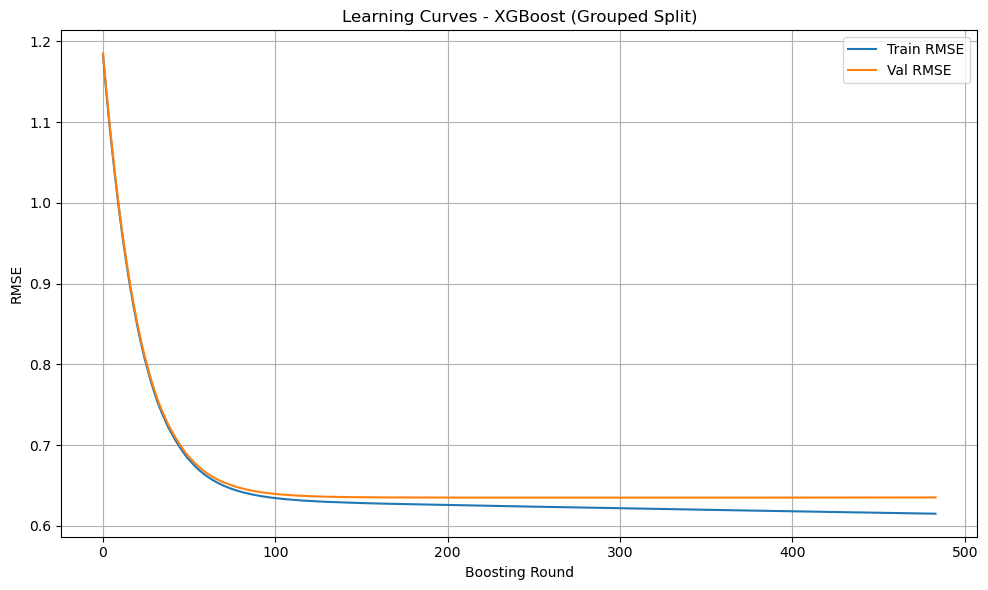

In [10]:
# === 1) Learning Curves ===
train_rmse = evals_result["validation_0"]["rmse"]
val_rmse = evals_result["validation_1"]["rmse"]

plt.figure(figsize=(10, 6))
plt.plot(train_rmse, label="Train RMSE")
plt.plot(val_rmse, label="Val RMSE")
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.title("Learning Curves - XGBoost (Grouped Split)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


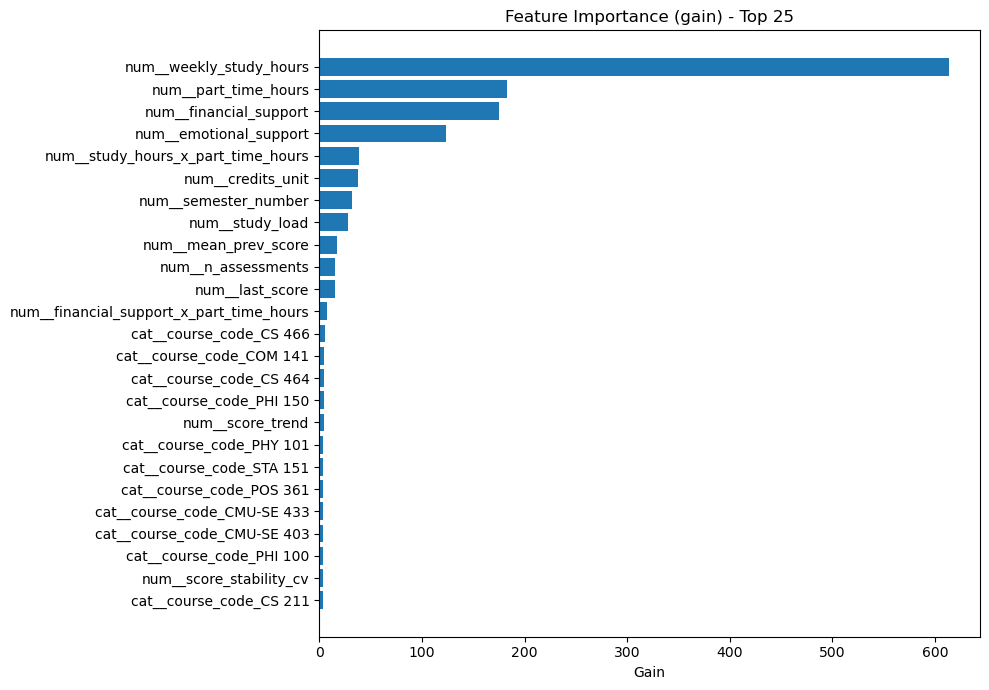

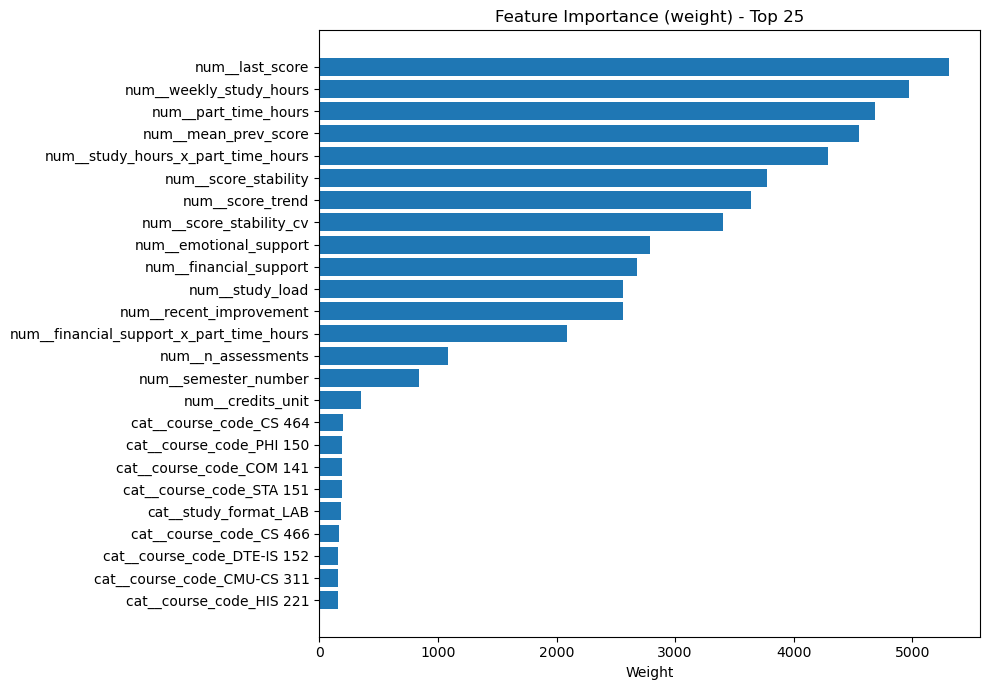

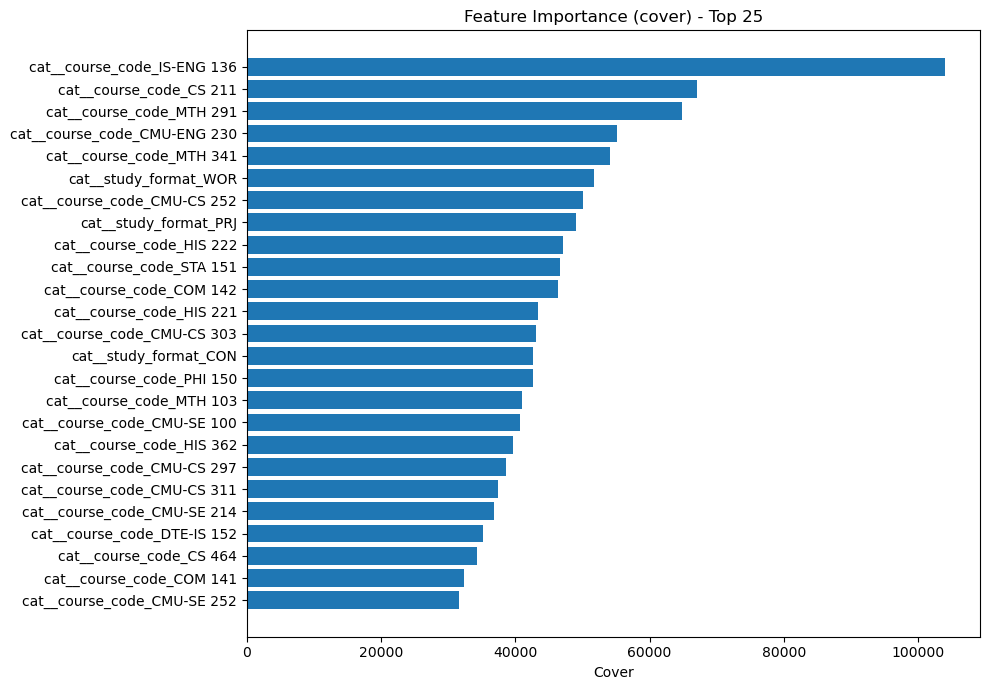

In [11]:
# === 2) Feature Importances (Gain, Weight, Cover) ===
booster = xgb_model.get_booster()

def plot_importance(importance_type, top_k=25):
    score = booster.get_score(importance_type=importance_type)
    if not score:
        print(f"No importance found for type={importance_type}")
        return

    # map f0..fn -> real names
    items = []
    for k, v in score.items():
        if k.startswith("f"):
            idx = int(k[1:])
            name = feature_names[idx] if idx < len(feature_names) else k
        else:
            name = k
        items.append((name, v))

    items = sorted(items, key=lambda x: x[1], reverse=True)[:top_k]
    names = [i[0] for i in items][::-1]
    vals = [i[1] for i in items][::-1]

    plt.figure(figsize=(10, 7))
    plt.barh(names, vals)
    plt.xlabel(importance_type.capitalize())
    plt.title(f"Feature Importance ({importance_type}) - Top {top_k}")
    plt.tight_layout()
    plt.show()

plot_importance("gain")
plot_importance("weight")
plot_importance("cover")


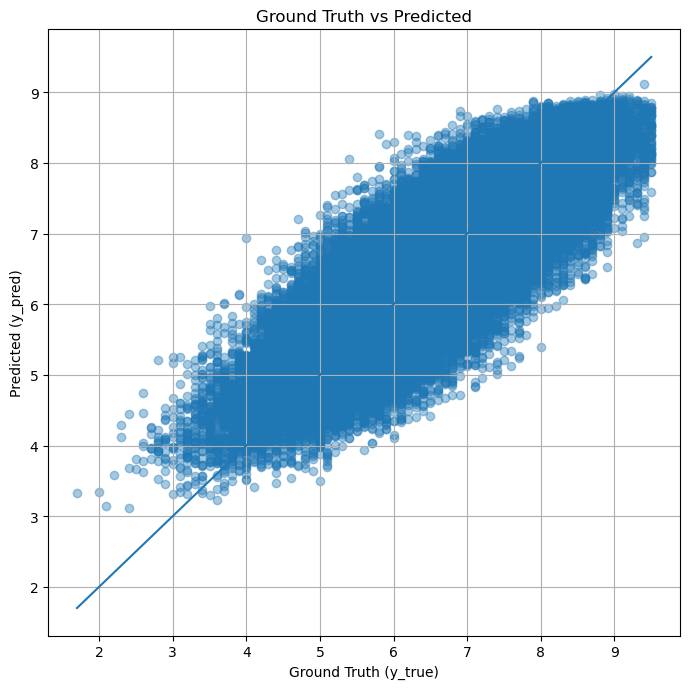

In [12]:
# === 3) Ground Truth vs Predicted ===
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test, alpha=0.4)
min_v = min(y_test.min(), y_pred_test.min())
max_v = max(y_test.max(), y_pred_test.max())
plt.plot([min_v, max_v], [min_v, max_v])
plt.xlabel("Ground Truth (y_true)")
plt.ylabel("Predicted (y_pred)")
plt.title("Ground Truth vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()


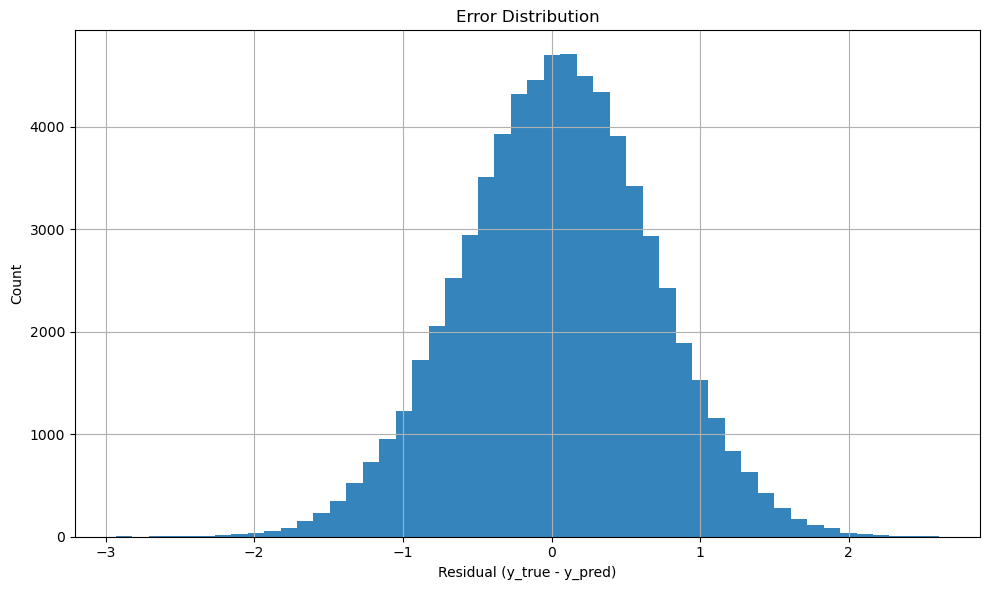

In [13]:
# === 4) Error distribution ===
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50, alpha=0.9)
plt.xlabel("Residual (y_true - y_pred)")
plt.ylabel("Count")
plt.title("Error Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()


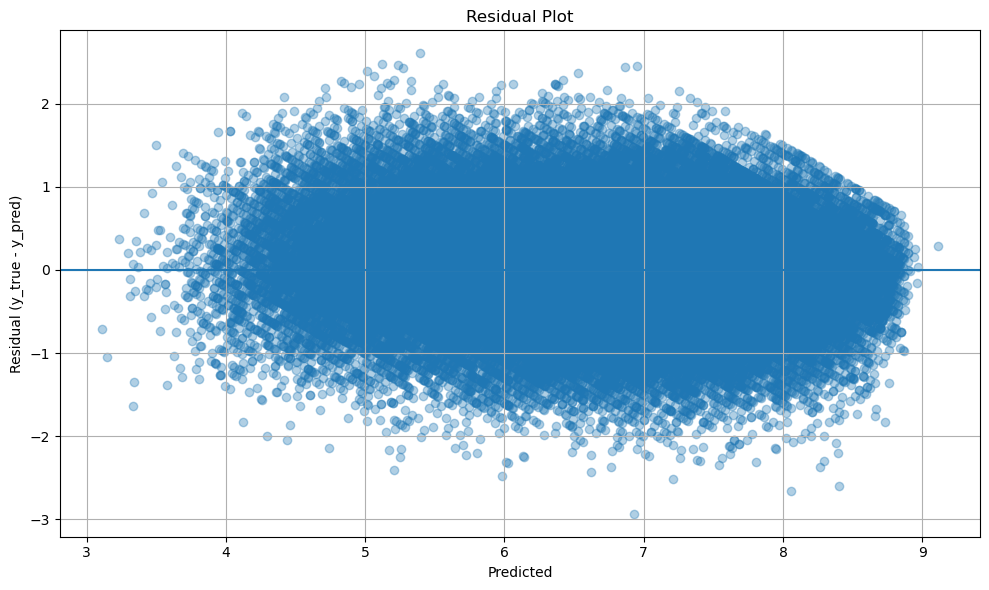

In [14]:
# === 5) Residual vs Predicted ===
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test, residuals, alpha=0.35)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residual (y_true - y_pred)")
plt.title("Residual Plot")
plt.grid(True)
plt.tight_layout()
plt.show()


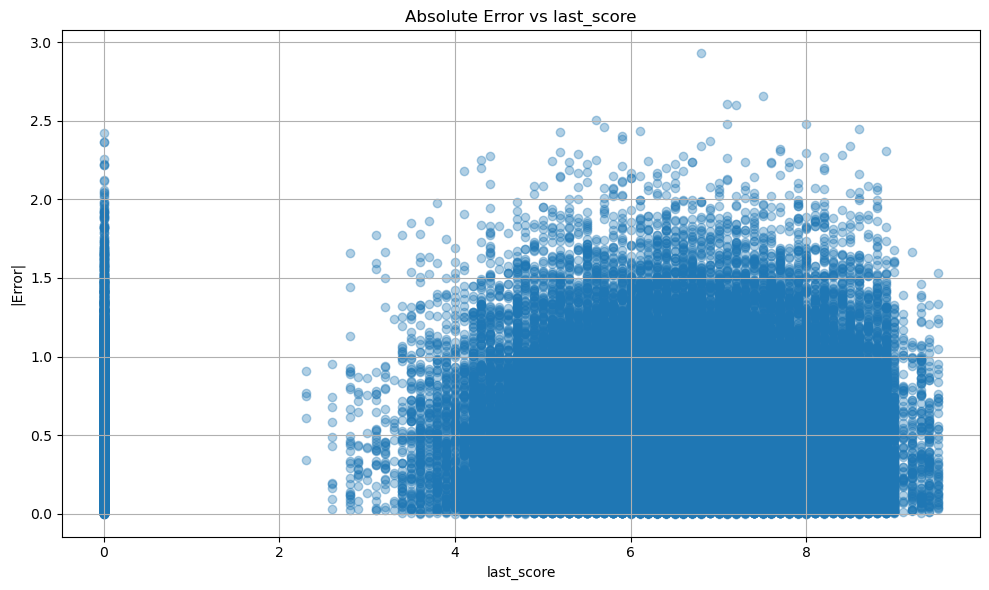

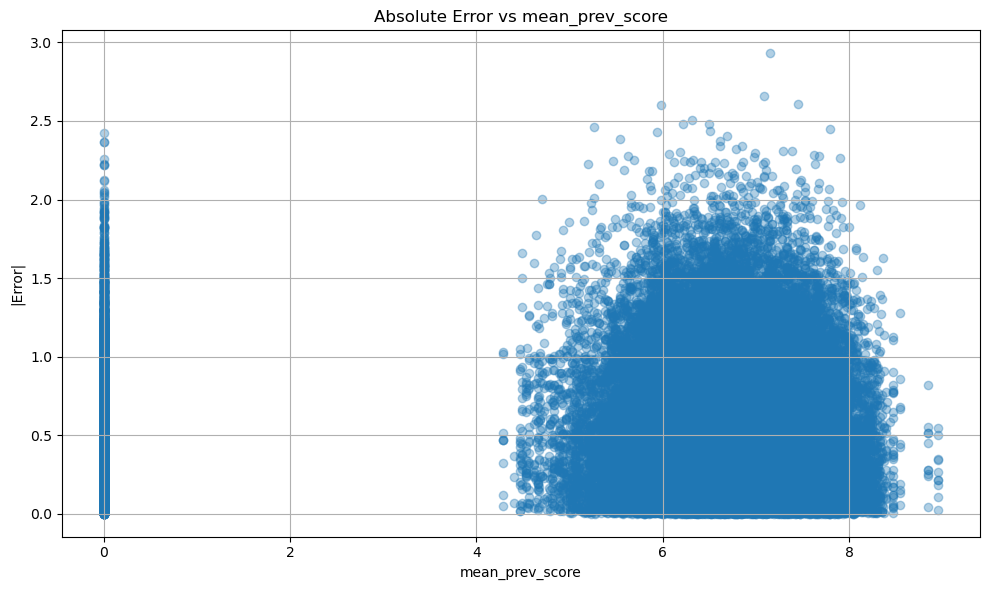

In [15]:
# === 6) Error vs Feature ===
def plot_error_vs_feature(X_raw, feature_name):
    if feature_name not in X_raw.columns:
        print(f"Skip: '{feature_name}' not in columns.")
        return

    plt.figure(figsize=(10, 6))
    plt.scatter(X_raw[feature_name], abs_errors, alpha=0.35)
    plt.xlabel(feature_name)
    plt.ylabel("|Error|")
    plt.title(f"Absolute Error vs {feature_name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_error_vs_feature(X_test_raw, "last_score")
plot_error_vs_feature(X_test_raw, "mean_prev_score")


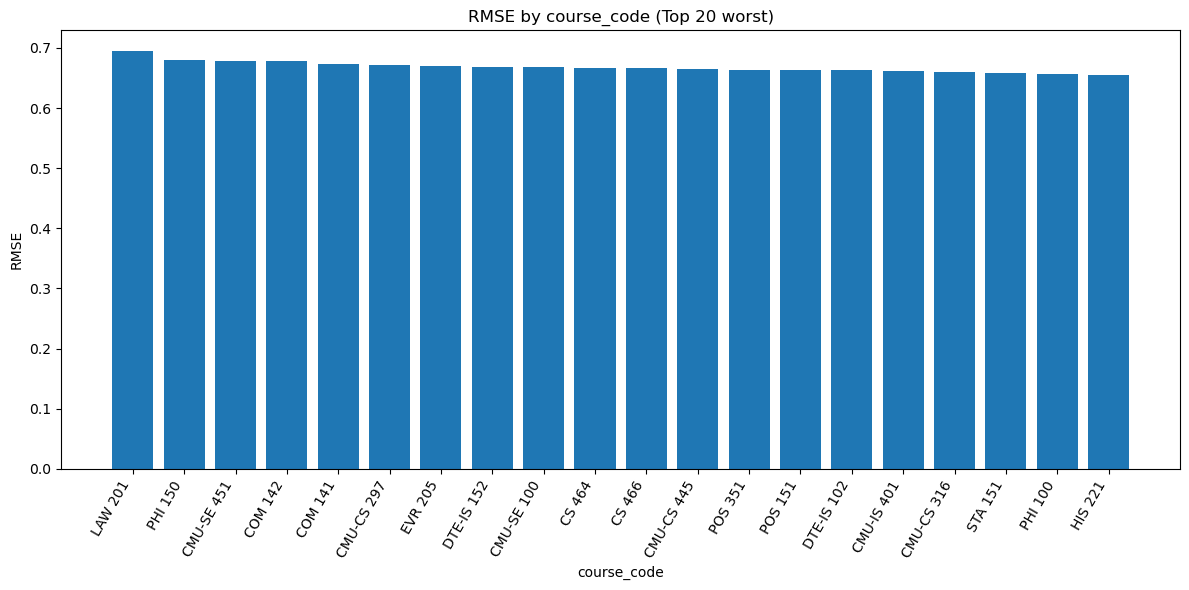

In [16]:
# === 7) Error by course / semester ===
def rmse_np(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def error_by_group_bar(X_raw, y_true, y_pred, group_col, top_k=30):
    if group_col not in X_raw.columns:
        print(f"Skip: '{group_col}' not in columns.")
        return

    tmp = pd.DataFrame({
        group_col: X_raw[group_col].astype(str),
        "y_true": y_true.values,
        "y_pred": y_pred
    })

    agg = tmp.groupby(group_col).apply(
        lambda g: rmse_np(g["y_true"].values, g["y_pred"].values)
    ).reset_index(name="RMSE")

    # Lọc nhóm có ít mẫu quá nhỏ nếu muốn
    counts = tmp[group_col].value_counts()
    agg["count"] = agg[group_col].map(counts)
    agg = agg.sort_values("RMSE", ascending=False)

    # Lấy top_k RMSE cao nhất để xem môn khó
    agg_top = agg.head(top_k)

    plt.figure(figsize=(12, 6))
    plt.bar(agg_top[group_col], agg_top["RMSE"])
    plt.xticks(rotation=60, ha="right")
    plt.xlabel(group_col)
    plt.ylabel("RMSE")
    plt.title(f"RMSE by {group_col} (Top {top_k} worst)")
    plt.tight_layout()
    plt.show()

    return agg

_ = error_by_group_bar(X_test_raw, y_test, y_pred_test, "course_code", top_k=20)
# Nếu bạn có cột semester/semester_number:
# _ = error_by_group_bar(X_test_raw, y_test, y_pred_test, "semester", top_k=20)


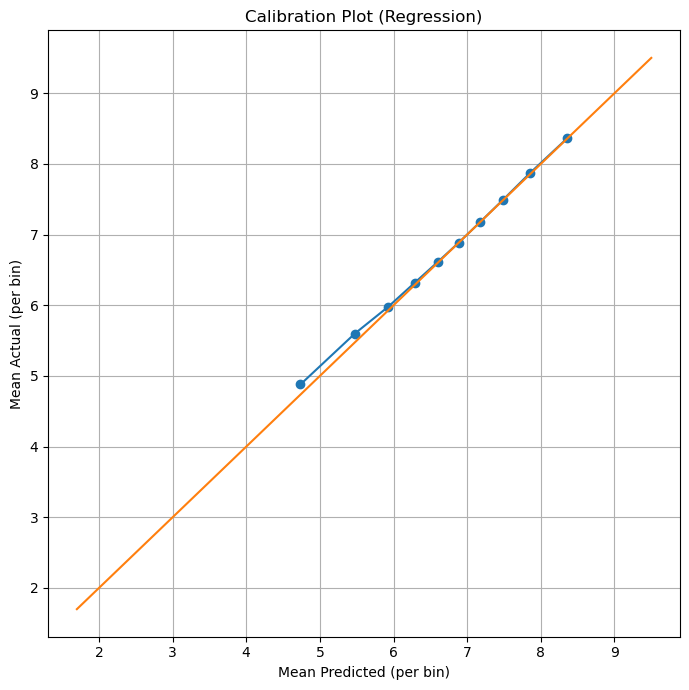

In [17]:
# === 8) Calibration Plot (Regression reliability-style) ===
def regression_calibration_plot(y_true, y_pred, n_bins=10):
    df_cal = pd.DataFrame({
        "y_true": y_true.values,
        "y_pred": y_pred
    })

    # Bin theo quantile của y_pred để mỗi bin có số lượng tương đối đều
    df_cal["bin"] = pd.qcut(df_cal["y_pred"], q=n_bins, duplicates="drop")

    grouped = df_cal.groupby("bin").agg(
        mean_pred=("y_pred", "mean"),
        mean_true=("y_true", "mean"),
        count=("y_true", "size")
    ).reset_index()

    plt.figure(figsize=(7, 7))
    plt.plot(grouped["mean_pred"], grouped["mean_true"], marker="o")
    # line lý tưởng
    min_v = min(df_cal["y_true"].min(), df_cal["y_pred"].min())
    max_v = max(df_cal["y_true"].max(), df_cal["y_pred"].max())
    plt.plot([min_v, max_v], [min_v, max_v])
    plt.xlabel("Mean Predicted (per bin)")
    plt.ylabel("Mean Actual (per bin)")
    plt.title("Calibration Plot (Regression)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return grouped

_ = regression_calibration_plot(y_test, y_pred_test, n_bins=10)


In [20]:
import numpy as np

# 1) Kiểm tra số chiều feature_names khớp với dữ liệu transform
assert X_tr.shape[1] == len(feature_names), (
    f"Feature names mismatch: X_tr has {X_tr.shape[1]} cols "
    f"but feature_names has {len(feature_names)}"
)

# 2) Kiểm tra model nhận đúng số feature
# Với XGBRegressor, số feature có thể lấy theo booster
booster = xgb_model.get_booster()
model_n_features = booster.num_features()

assert model_n_features == X_tr.shape[1], (
    f"Model expects {model_n_features} features "
    f"but preprocessor outputs {X_tr.shape[1]}"
)

print("[OK] Preprocessor output dim, feature_names, and model num_features are consistent.")
print("Feature dim =", X_tr.shape[1])


[OK] Preprocessor output dim, feature_names, and model num_features are consistent.
Feature dim = 79


In [21]:
import os
import joblib
import numpy as np

EXPORT_DIR = "artifacts_xgb_v1"
os.makedirs(EXPORT_DIR, exist_ok=True)

# 1) Save preprocessing pipeline
preprocessor_path = os.path.join(EXPORT_DIR, "preprocessing_pipeline.joblib")
joblib.dump(preprocessing_pipeline, preprocessor_path)

# 2A) Save XGBoost model as JSON (khuyến nghị)
model_json_path = os.path.join(EXPORT_DIR, "xgb_model.json")
xgb_model.get_booster().save_model(model_json_path)

# 2B) (Tuỳ chọn) Save full sklearn wrapper bằng joblib
model_joblib_path = os.path.join(EXPORT_DIR, "xgb_model.joblib")
joblib.dump(xgb_model, model_joblib_path)

# 3) Save feature names
feature_names_path = os.path.join(EXPORT_DIR, "feature_names.npy")
np.save(feature_names_path, feature_names)

print("Exported:")
print(" -", preprocessor_path)
print(" -", model_json_path)
print(" -", model_joblib_path)
print(" -", feature_names_path)


Exported:
 - artifacts_xgb_v1\preprocessing_pipeline.joblib
 - artifacts_xgb_v1\xgb_model.json
 - artifacts_xgb_v1\xgb_model.joblib
 - artifacts_xgb_v1\feature_names.npy


In [22]:
import json

meta = {
    "target": "raw_score",
    "feature_dim": int(X_tr.shape[1]),
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "use_full_interaction": bool(USE_FULL_INTERACTION),
    "drop_columns": DROP_COLUMNS,
    "random_state": int(RANDOM_STATE),
}

meta_path = os.path.join(EXPORT_DIR, "metadata.json")
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(" -", meta_path)


 - artifacts_xgb_v1\metadata.json
